In [238]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [239]:
#1. import database/ data


In [240]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type = "table"
"""

tables = pd.read_sql(sql_query,conn)

# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [241]:
# print table names and column names

conn = sqlite3.connect('customer_churn.db')

for table_name in tables["name"]:
    print(f"\nTable Name:{table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns["name"].tolist())

# Close connection

conn.close()


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [242]:
# 2. Data Cleaning

In [243]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [244]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [245]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [246]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country


In [247]:
# a. rename col - name



df_db_customer.rename(columns = {"name" : "customer_name"},inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [248]:
# b. drop columns - interest and pinco

#df_db_customer.drop(df_db_customer.columns[-2:],axis = 1)
# df_db_customer.columns[-2:]
#df_db_customer.drop(df_db_customer.columns[6:],axis = 1)

df_db_customer.drop(columns = ['interests','pincode'],inplace = True)


In [249]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [250]:
# c. change data type - dob


df_db_customer["dob"] = pd.to_datetime(df_db_customer["dob"])

In [251]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [252]:
# d. data standardization - gender


df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [253]:
df_db_customer['gender'] = df_db_customer['gender'].replace({"Men":"Male","Women" : "Female"})

In [254]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [255]:
# e. fix missing values - country

#df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [256]:
#df_db_customer[['country',"state"]]

In [257]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index("state")["country"].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [258]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [259]:
#df_db_customer[['country','state']]

In [260]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [261]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [262]:
date_col = [ 'subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [263]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [264]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [265]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [266]:

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [267]:
# 3. Feature Engineering & Data Analysis

In [268]:

np.where(df_db_subscription['cancellation_date'].notna(),1,0)

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [269]:
# createa new column using existing column = churn flag
df_db_subscription["churn_flag"] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [270]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [271]:
# first fix support table duplicates then merge
df = (df_db_subscription
                 .merge(df_db_customer, on = 'customerid',how = 'left')
                 .merge(df_db_support, on = 'customerid',how = 'left'))

In [272]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [273]:
df_db_subscription.shape

(21, 12)

In [274]:
df.shape

(23, 20)

In [275]:
df_db_subscription['customerid'].nunique()

21

In [276]:
df_db_customer['customerid'].nunique()

21

In [277]:
df_db_support['customerid'].nunique()

7

In [278]:
df_db_support['customerid'].size

9

In [279]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [280]:
df_db_support['complaint_count'] = df_db_support.groupby("customerid")["customerid"].transform("count")

In [281]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [282]:
df_db_support = df_db_support.sort_values("complaint_date").drop_duplicates("customerid",keep = 'last')

In [283]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [284]:
df_db_support['customerid'].size

7

In [285]:
# merge df

df = (df_db_subscription
                 .merge(df_db_customer, on = 'customerid',how = 'left')
                 .merge(df_db_support, on = 'customerid',how = 'left'))

In [286]:
df.shape

(21, 21)

In [287]:
df.to_csv('exported_churn_data.csv',index = False)

In [288]:
# Data Analysis


In [289]:
# 1. Churn Rate

In [290]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [291]:
churn_rate = df["churn_flag"].mean()*100
print("Churn Rate = ", round(churn_rate,2),'%')

Churn Rate =  28.57 %


In [292]:
# 2. Retention Rate

retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2),'%')

Retention Rate =  71.43 %


In [293]:
# 3. Churn by plan type

churn_by_plan = (df.groupby("plan_type")["churn_flag"].mean().mul(100).round(2).reset_index(name = "churn_rate_pct"))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [294]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [295]:
# 4.
# a. Churn by state + sum(revenue) & count of users
# b. Churn by subscription type + sum(revenue) & count of users

In [296]:
# a. Churn by state + sum(revenue) & count of users

churn_by_state = df.pivot_table(
    index="state",
    values=["churn_flag", "monthly_charges", "customerid"],
    aggfunc={
        "churn_flag": "mean",       # churn rate
        "monthly_charges": "sum",   # total revenue from that state
        "customerid": "nunique"     # count of unique users
    }
)

churn_by_state["churn_flag"] = (churn_by_state["churn_flag"] * 100).round(2)
churn_by_state = churn_by_state.rename(columns={
    "churn_flag": "churn_rate_pct",
    "monthly_charges": "total_revenue",
    "customerid": "user_count"
})

print(churn_by_state)

               churn_rate_pct  user_count  total_revenue
state                                                   
Delhi                   25.00           4          52.96
Karnataka              100.00           2          20.98
Kathmandu                0.00           2          20.98
Maharashtra              0.00           3          50.97
Meghalaya               66.67           3          42.97
Nagaland                 0.00           1          22.99
Rajasthan                0.00           2          36.98
Telangana               50.00           2          30.98
Uttar Pradesh            0.00           2         115.98


In [297]:
# b. Churn by subscription type + sum(revenue) & count of users

churn_by_subtype = df.pivot_table(
    index="subscription_type",
    values=["churn_flag", "monthly_charges", "customerid"],
    aggfunc={
        "churn_flag": "mean",
        "monthly_charges": "sum",
        "customerid": "nunique"
    }
)

churn_by_subtype["churn_flag"] = (churn_by_subtype["churn_flag"] * 100).round(2)
churn_by_subtype = churn_by_subtype.rename(columns={
    "churn_flag": "churn_rate_pct",
    "monthly_charges": "total_revenue",
    "customerid": "user_count"
})

print(churn_by_subtype)

                   churn_rate_pct  user_count  total_revenue
subscription_type                                           
Organic                      0.00           9         145.91
Paid                        16.67           6         174.94
Refferal                    83.33           6          74.94


In [298]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [299]:
# 5. ARPU - Avg Revenue per user

arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [300]:
# calculate customer age

In [301]:
# 6. Avg Customer Tenure
# count of days  users has used our service : cancellation date else current date

today = pd.Timestamp.today()


df["tenure_days"] = np.where(
          df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
    
)

avg_tenure = df["tenure_days"].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1499 0


In [302]:
# 7. Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df["churn_flag"] == 1, "monthly_charges"].sum()

print("Revenue at Risk  (Rs 'K') =", revenue_at_risk)

Revenue at Risk  (Rs 'K') = 73.94


In [303]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1953.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1338.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2628.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [304]:
# 8. Esclation Rate
df['escalations'].unique()

array([nan, 'Y', 'N'], dtype=object)

In [305]:


escalation_rate = (df['escalations'] == "Y").mean()* 100
print("Escalation Rate =", round(escalation_rate, 2),"%")

Escalation Rate = 19.05 %


In [306]:
# 9. Avg Complaint Per User

avg_complaints = df["complaint_count"].sum()/df["customerid"].nunique()
print("AVg Complaints Per User = ", round(avg_complaints,2))

AVg Complaints Per User =  0.43


In [307]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [308]:
corr_df = df[["escalations",'churn_flag']].dropna()
corr_df

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [309]:
print(df["escalations"].unique())

[nan 'Y' 'N']


In [310]:
print(df["escalations"].value_counts(dropna=False))

escalations
NaN    14
Y       4
N       3
Name: count, dtype: int64


In [311]:
df['escalations'] = np.where(df['escalations'] == "Y",1,0) # encoding string to int type

In [312]:
corr_df = df[["escalations",'churn_flag']].dropna()
corr_df

,escalations,churn_flag
0,0,0
1,1,1
2,0,0
3,0,0
4,1,1
5,0,0
6,0,1
7,0,0
8,0,0
9,0,0


In [313]:
print(df["escalations"].unique())

[0 1]


In [314]:
# 10. Correlation Escalation vs Churn


#df['escalations'] = np.where(df['escalations'] == "Y",1,0) # encoding string to int type


correlation = corr_df["escalations"].corr(df["churn_flag"])
print("Correlation between escalltion vs churn is =", round(correlation,2))

Correlation between escalltion vs churn is = 0.77


In [315]:
# 11. Churn Risk - create  column using existing col

conditions = [
    (df["churn_score"] < 50),
     (df["churn_score"] >= 50) & (df["churn_score"] < 70),
     (df["churn_score"] >= 70)
    
]

choices = ['low','medium','high']

df["churn_risk"] = np.select(conditions,choices, default = "unknown")

In [316]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,medium,62
17,low,27
18,high,99
19,low,7
20,low,47


In [317]:
# 4. Visualization using Matplotlib

In [318]:
df_visual = df.copy()

In [319]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1953.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1338.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2628.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [320]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

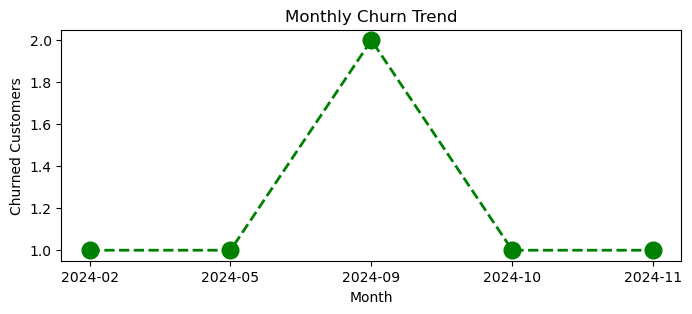

In [321]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period("M")

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby("cancellation_month").size()


plt.figure(figsize = (8,3))
plt.plot(churn_trend.index.astype("str"),churn_trend.values,color = 'green', marker ="o",linestyle = "dashed",linewidth = 2, markersize = 12)

plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

<BarContainer object of 3 artists>

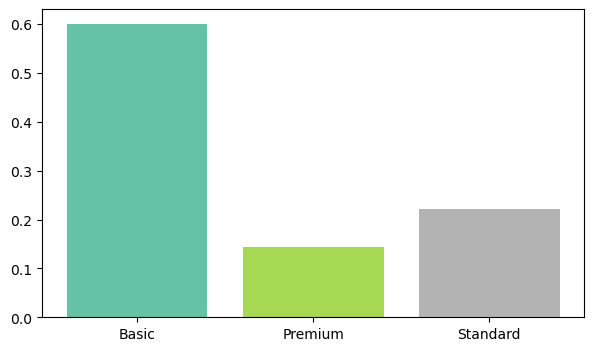

In [322]:
# 4.2 Churn by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['blue','orange','purple']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

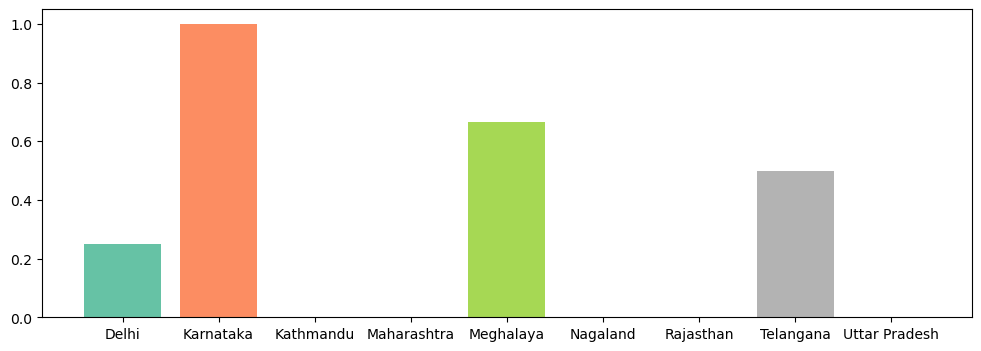

In [323]:
# 4.3 Churn by State

churn_plan = df_visual.groupby("state")["churn_flag"].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [324]:
# Visualization using Seaborn

In [325]:
# encoding - convert str to numeric so that we can find corr between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [326]:

df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [327]:
#df_encoded.head()

In [328]:
import warnings
warnings.filterwarnings("ignore")

In [329]:
# Incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols = ["plan_type","contract_type","churn_risk"]

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

<Axes: >

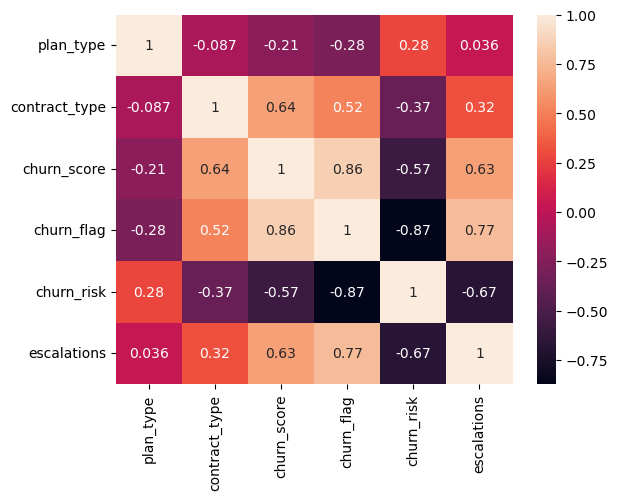

In [330]:
# Heatmap ( correlation matrix)

sns.heatmap(df_encoded.corr(),annot = True)


In [331]:
df_visual["churn_risk"].unique()

array(['low', 'high', 'medium'], dtype=object)

In [332]:
 # Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]


order_mappings  = {
    "plan_type":['Basic','Standard','Premium'],
                "contract_type":["Monthly","Annual"]
                ,"churn_risk":['low', 'medium',"high"]} 


for col, order  in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories = order, ordered = True).codes

In [333]:
 df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [334]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

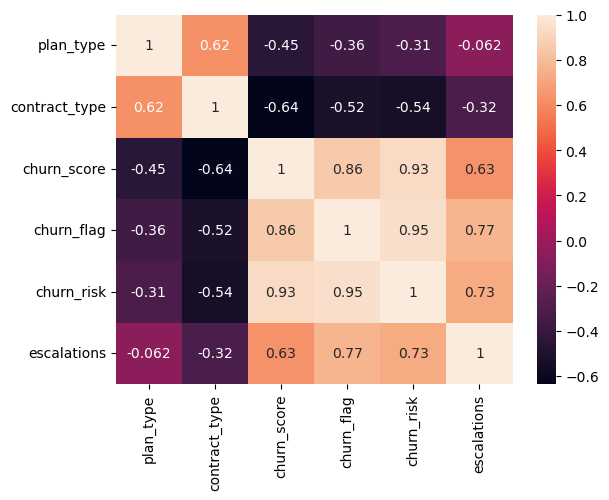

In [335]:
# Heatmap ( correlation matrix)

sns.heatmap(df_encoded.corr(),annot = True)


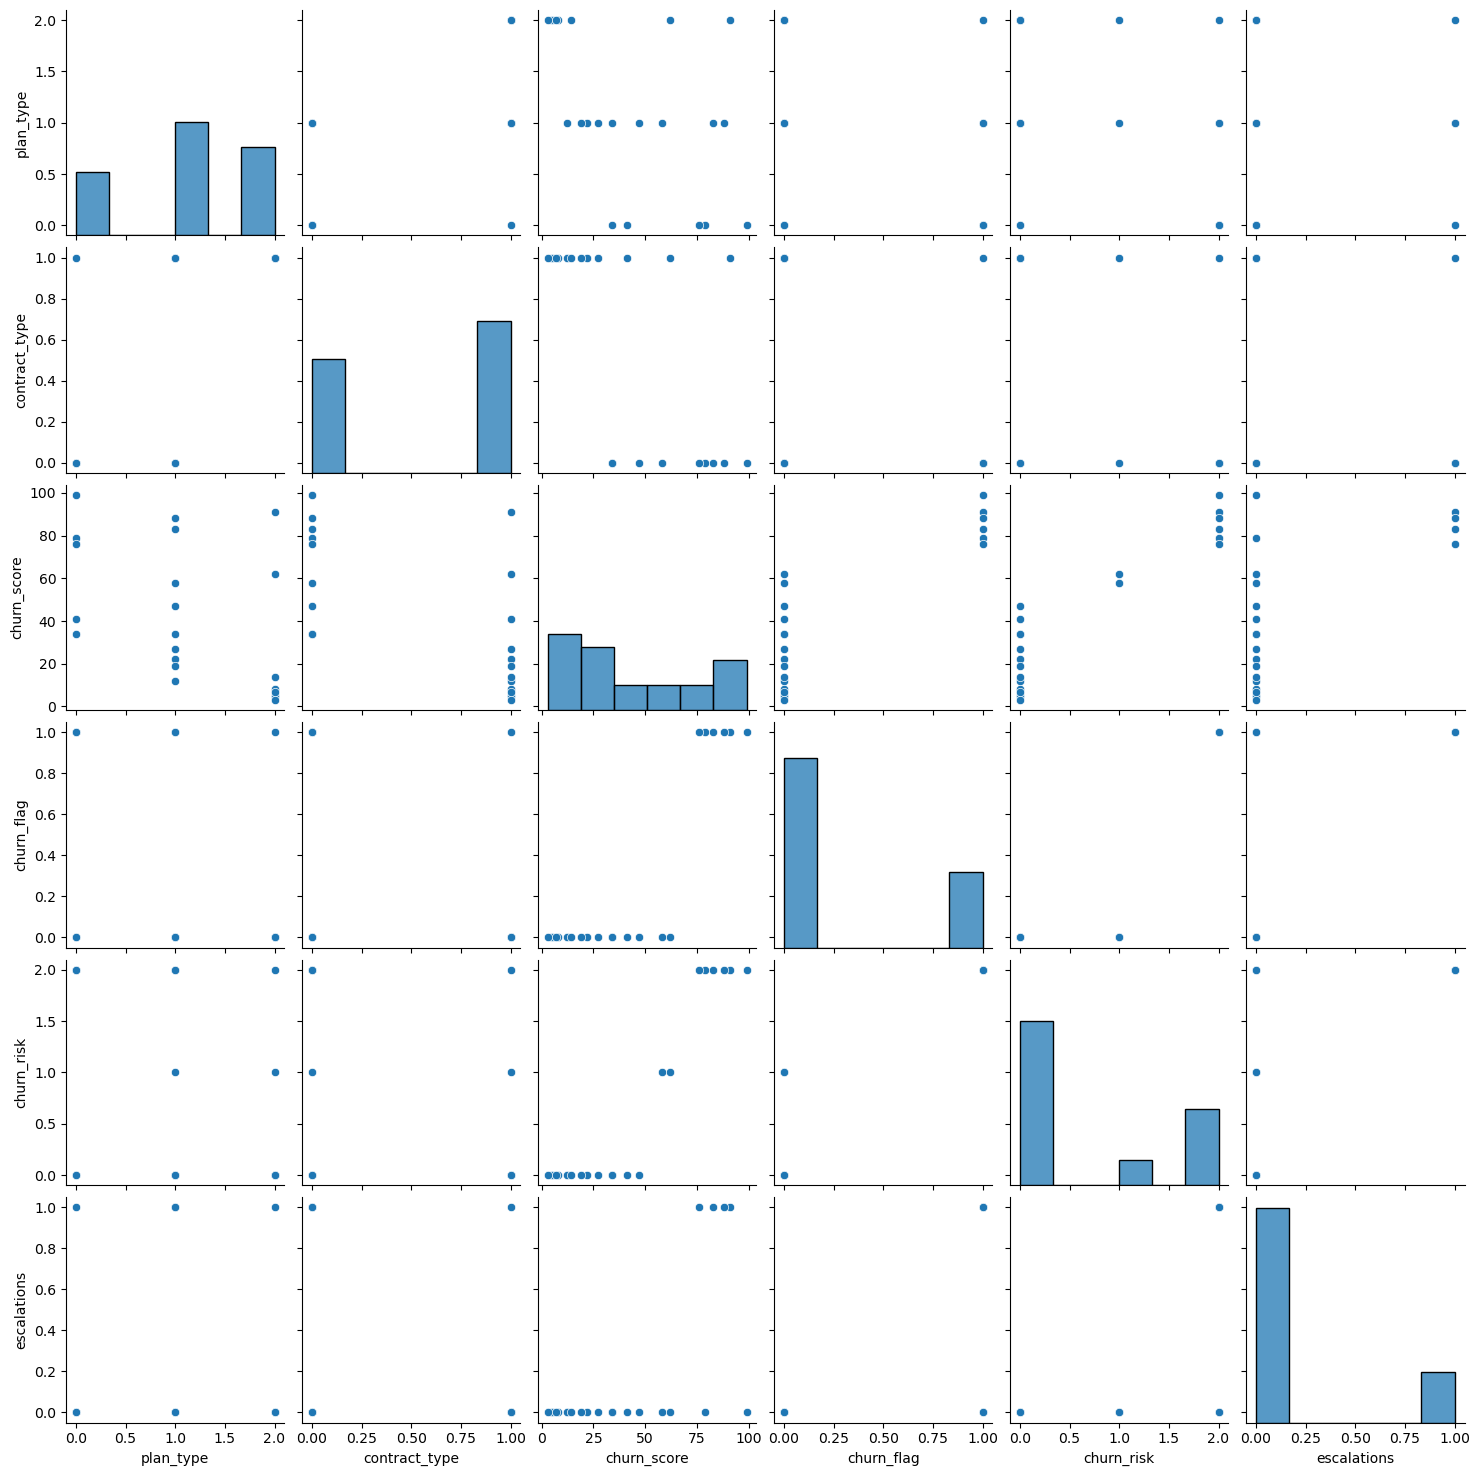

In [336]:
# pairplot - relationship in a dataset

sns.pairplot(df_encoded)

In [337]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

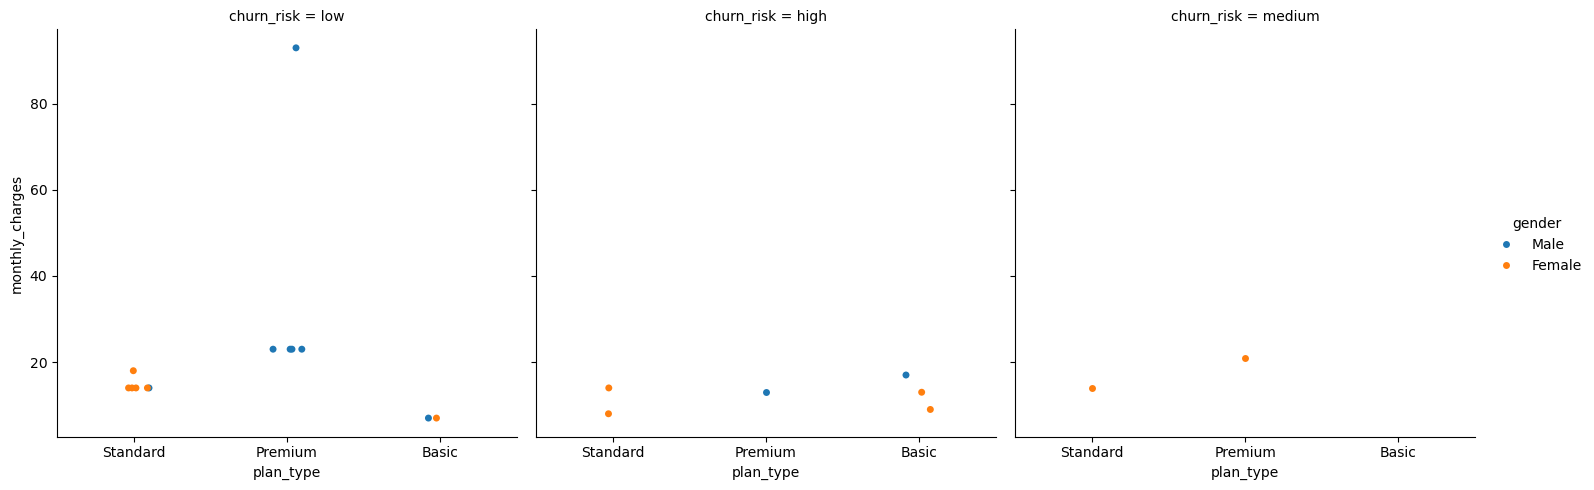

In [338]:
# catplt/ Facegrid plot -  multi-dim comparision

sns.catplot(
    data = df_visual,
    x = 'plan_type',
    y = "monthly_charges",
    hue = "gender",
    col = "churn_risk"
)

In [339]:
# Pivot Table

In [340]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc= "mean"
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [341]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [342]:
pd.pivot_table(df_visual,
              index = "plan_type",
              values = ['monthly_charges','customerid','churn_flag'],
               aggfunc = {
                   'monthly_charges': "sum",
                   'customerid': "nunique",
                   'churn_flag': "mean"
               }
              )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [343]:
# Working with SQL in Python (pandas)


In [344]:
# Create db in sql

conn = sqlite3.connect('test_database.sqlite')

# table details

conn.execute("CREATE TABLE  users (first_name TEXT,  country TEXT, budget INTEGER)")


# commit and save
conn.commit()

OperationalError: table users already exists

In [ ]:
# insert data

cursor = conn.cursor()

# Write sql query to insert reccords in sql table
cursor.execute(
    """
    INSERT INTO users VALUES 
    ("Madhav","India",5000),
    ("Rishabh","Germany",2500),
    ("Vishakha","India",3500)
  
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

In [ ]:
# Check Inserted Data in table

conn = sqlite3.connect("test_database.sqlite")
query = """
       SELECT * FROM users
"""

df_results = pd.read_sql(query, conn)

df_results.head()

In [ ]:
# Aggregation

query = """
        SELECT  country, sum(budget) as total_budget
        FROM users
        GROUP BY country
        """

df_agg = pd.read_sql(query,conn)
df_agg

In [ ]:
# Always close the conn with db once the task is over

conn.close()